# Classic Vectorization techniques

Bag of words

In [ ]:
import numpy as np
import pandas as pd
import string
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
text = ["Hello world, this is a trial text.","hello world, welcome"]
cv = CountVectorizer(max_features=7)
bow = cv.fit_transform(text).toarray()
print(bow)


[[1 1 1 1 1 0 1]
 [1 0 0 0 0 1 1]]


TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf_vec = TfidfVectorizer()
res = tf_vec.fit_transform(text)
for e1,e2 in zip(tf_vec.get_feature_names_out(),tf_vec.idf_):
  print(f"{e1} : {e2}")

hello : 1.0
is : 1.4054651081081644
text : 1.4054651081081644
this : 1.4054651081081644
trial : 1.4054651081081644
welcome : 1.4054651081081644
world : 1.0


# Word Embedding Techniques

CBOW : Continous Bag of Words

In [ ]:
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/alpino.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping
[nltk_data]    |       taggers/averaged_perceptron_tagger_ru.zip.
[nltk_data]    | Downloading package averaged_perceptron_tagger_rus to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |  

True

In [ ]:
import torch
from torch import nn
from torch.nn.functional import one_hot
import spacy
import nltk
from nltk.corpus import stopwords
from sklearn.preprocessing import OneHotEncoder
import numpy as np
import pandas as pd
from nltk.tokenize import word_tokenize


text = ["Hello this text is for trial purpose.","CPU is the main component of a Computer"]
nlp = spacy.load("en_core_web_sm")
encoder = OneHotEncoder(sparse_output=False)
all_tokens = [str(token) for sentence in text for token in nlp(sentence)]
encoder.fit(np.array(all_tokens).reshape(-1,1))

def CBOW_data_gen(window_size=2):
  X = []
  y = []

  for sentence in text:

    doc = [str(word) for word in nlp(sentence)]

    for i,target in enumerate(doc):
      context_vect = []

      for j in range(i-window_size,i+window_size+1):

        if i == j:
          continue

        if 0 < j and j < len(doc):

          context_word = doc[j]
          encoded_vec = encoder.transform(np.array([[context_word]])).flatten()
          context_vect.append(encoded_vec)

    if context_vect:
      summed_context = np.sum(context_vect,axis=0)
      target_vec = encoder.transform(np.array([[target]])).flatten()

      X.append(summed_context)
      y.append(target_vec)

  return np.array(X),np.array(y)


In [ ]:
class CBOW_model(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=15,out_features=32,bias=False)
    self.layer2 = nn.Linear(in_features=32,out_features=15,bias=False)

  def forward(self,x):
    x = self.layer1(x)
    x = self.layer2(x)
    return x


In [ ]:
X_train, y_train = CBOW_data_gen(2)
X_train = torch.tensor(X_train,dtype=torch.float)
y_train = torch.tensor(y_train,dtype=torch.float)
print(X_train)

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])


In [ ]:
model = CBOW_model()
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters())

for epoch in range(500):
  optimizer.zero_grad()
  preds = model(X_train)

  loss = loss_function(preds,y_train)

  loss.backward()
  optimizer.step()

final_embedding = model.layer1.weight
print(final_embedding[0])

tensor([ 0.0257, -0.1001, -0.1949, -0.0361, -0.2004,  0.1753,  0.1210,  0.1366,
        -0.2156,  0.0547,  0.0753, -0.1857, -0.2387, -0.1571,  0.1543],
       grad_fn=<SelectBackward0>)


**SkipGram**

In [74]:
import string
import torch
from torch import nn
import nltk
from nltk.corpus import stopwords
import numpy as np
import pandas as pd
from nltk.tokenize import word_tokenize
device = "cuda" if torch.cuda.is_available() else "cpu"
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

In [ ]:
import kagglehub
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print(path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
/kaggle/input/imdb-dataset-of-50k-movie-reviews


In [ ]:
df = pd.read_csv("/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")


In [ ]:
def preprocess_txt(text):
  final_out = []
  text = text.lower()
  text = text.translate(str.maketrans("","",string.punctuation))
  tokens = word_tokenize(text)
  stop_words = set(stopwords.words('english'))

  for token in tokens:
    if token not in stop_words and token.isnumeric() == False:
      final_out.append(token)
  return final_out

In [ ]:
def create_context_target_pair(tokens,window_size=2):
  context_pairs = []
  for i in range(window_size,len(tokens)-window_size):
    target = tokens[i]
    context = tokens[i-window_size:i+window_size+1]
    context.remove(target)

    for word in context:
      context_pairs.append((target,word))

  return context_pairs


In [ ]:
def create_vector_representation(tokens):
  vocab = sorted(set(tokens))
  word2idx = {word : idx for idx,word in enumerate(vocab)}
  idx2word = {idx : word for idx,word in enumerate(vocab)}

  return vocab , word2idx, idx2word



In [81]:
text = df['review'].iloc[:10000]
text = text.apply(preprocess_txt)
text.head()
tokens = [token for sentence in text for token in sentence]

In [82]:
vocab, word2idx, idx2word = create_vector_representation(tokens)

In [83]:
context_target_pair = create_context_target_pair(tokens)

In [84]:
X_train = []
y_train = []

for target,context in context_target_pair:

  X_train.append(word2idx[context])
  y_train.append(word2idx[target])

X_train = torch.tensor(X_train,dtype=torch.long).to(device)
y_train = torch.tensor(y_train,dtype=torch.long).to(device)

In [85]:
class SkipGram(nn.Module):
  def __init__(self,vocab_size,emmeb_size):
    super().__init__()
    self.layer1 = nn.Embedding(vocab_size,emmeb_size)
    self.layer2 = nn.Linear(in_features=emmeb_size,out_features=vocab_size)

  def forward(self,x):
    x = self.layer1(x)
    x = self.layer2(x)
    return x

In [ ]:
vocab_size = len(vocab)
print(vocab_size)
batch_size = 16
emmeb_size = 300
model = SkipGram(vocab_size,emmeb_size).to(device)
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

for epoch in range(50):
  total_loss = 0.0

  for i in range(0,len(X_train),batch_size):
    optimizer.zero_grad()
    x = X_train[i:i+batch_size].to(device)
    y_true = y_train[i:i+batch_size].to(device)

    y_preds = model(x)
    loss = loss_function(y_preds, y_true.view(-1))
    loss.backward()

    optimizer.step()
    total_loss = total_loss + loss.item()

  print(f"Epoch : {epoch+1} | loss : {total_loss:.4f}")



Text(0.5, 1.0, 'Pickle Rick Word Embeddings Visualization ')

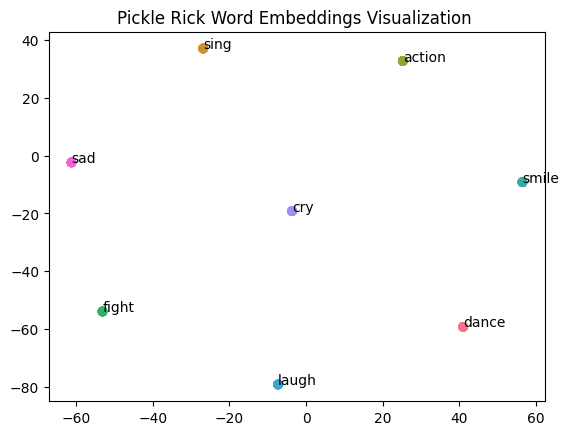

In [80]:
words_to_visualize = ['dance','sing','action','fight','smile','laugh','cry','sad']
word_vectors = model.layer1.weight.data

indices = [word2idx[word] for word in words_to_visualize]
word_vectors = model.layer1.weight.data[indices]
tsne = TSNE(n_components=2,perplexity=7)
word_vectors_2d = tsne.fit_transform(word_vectors.cpu())
colors = sns.husl_palette(n_colors = len(words_to_visualize))
for i, word in enumerate(words_to_visualize):
  plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1],c=colors)
  plt.annotate(word, xy=(word_vectors_2d[i, 0], word_vectors_2d[i, 1]))

plt.title(f'Pickle Rick Word Embeddings Visualization ')